Final SNN Implementation (Paper-Reproduced)

In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import BertTokenizer, TFBertModel
import arff
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ==========================
# Step 1: Load data
# ===========================

#step 1 completed

shadow_df = pd.read_csv("datasets/shadow_train.csv")

In [18]:
print(shadow_df.head())

        uid1                                              text1       uid2  \
0  6161574-1  A 39-year-old male presented with a history of...  7280936-1   
1  3355874-1  A 5.9-year-old male presented with short statu...  4124264-1   
2  5289268-1  A 92-year-old female with a history of hyperte...  5289268-5   
3  7069865-1  A 75-year-old man had a regular visit for COPD...  7069865-3   
4  4323975-1  We admitted a 6-year-old male child who presen...  5965193-1   

                                               text2  label  
0  A 28-year-old woman with generalized dystonia ...      0  
1  We report a 41-year-old male patient known to ...      0  
2  An 11-year-old female with no past medical his...      1  
3  An 89-year-old man with a history of COPD (GOL...      1  
4  A six-year-old female presented to a small rur...      0  


In [ ]:
''' Only run code to generate embeddings once.

# Step 3: Generate embeddings only for train and test separately
import numpy as np
from transformers import BertTokenizer, TFBertModel
import tensorflow as tf
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore") 

k = 5; #number of shadows

# # Load ClinicalBERT
tokenizer = BertTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
bert_model = TFBertModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

# # Helper function for batched embedding generation
def generate_embeddings_batched(texts, batch_size=32, max_length=512):
     all_embeddings = []
     n_batches = (len(texts) + batch_size - 1) // batch_size

# # Wrapped in tqdm for progress bar
     for i in tqdm(range(0, len(texts), batch_size),total=n_batches, desc="Generating embeddings"):
         batch = texts.iloc[i:i+batch_size].tolist()
         inputs = tokenizer(
             batch,
             return_tensors="tf",
             padding=True,
             truncation=True,
             max_length=max_length  # Truncate to 512 tokens
         )
         outputs = bert_model(inputs["input_ids"])
         cls_embeddings = outputs.last_hidden_state[:, 0, :]  # [CLS] token
         all_embeddings.append(cls_embeddings.numpy())

     return np.vstack(all_embeddings)

# # Generate multiple shadow models 

for i in range(k):
    print(f"\n--- Training shadow model {i+1}/{k} ---")

    train_df, test_df = train_test_split(
        shadow_df, test_size=0.2, random_state=i*42, stratify=shadow_df['label']
    )
    print("Train split Complete")

# # Encode and save embeddings
    x1_train = generate_embeddings_batched(train_df['text1'])
    x2_train = generate_embeddings_batched(train_df['text2'])
    y_train = train_df['label'].values.astype(np.float32)

    x1_test = generate_embeddings_batched(test_df['text1'])
    x2_test = generate_embeddings_batched(test_df['text2'])
    y_test = test_df['label'].values.astype(np.float32)
    print("Embeddings generated")

# # Save embeddings for this shadow model
    np.save(f"embeddings/shadows/x1_shadow_train{i}.npy", x1_train)
    np.save(f"embeddings/shadows/x2_shadow_train{i}.npy", x2_train)
    np.save(f"embeddings/shadows/y_shadow_train{i}.npy", y_train)
    np.save(f"embeddings/shadows/x1_shadow_test{i}.npy", x1_test)
    np.save(f"embeddings/shadows/x2_shadow_test{i}.npy", x2_test)
    np.save(f"embeddings/shadows/y_shadow_test{i}.npy", y_test)
    print(f"Embeddings for shadow model {i+1} saved.")

print("\nAll shadow models trained and embeddings saved.")
# step 3 completed

'''

Some layers from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT were not used when initializing TFBertModel: ['mlm___cls', 'nsp___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertModel were initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training.



--- Training shadow model 1/5 ---
Train split Complete


Generating embeddings: 100%|██████████| 200/200 [30:36<00:00,  9.18s/it]


Embeddings generated
Embeddings for shadow model 1 saved.

--- Training shadow model 2/5 ---
Train split Complete


Generating embeddings: 100%|██████████| 200/200 [31:10<00:00,  9.35s/it]


...

Embeddings generated
Embeddings for shadow model 3 saved.

--- Training shadow model 4/5 ---
Train split Complete


Generating embeddings: 100%|██████████| 200/200 [31:50<00:00,  9.55s/it]


Embeddings generated
Embeddings for shadow model 4 saved.

--- Training shadow model 5/5 ---
Train split Complete


Generating embeddings: 100%|██████████| 200/200 [31:24<00:00,  9.42s/it]


Embeddings generated
Embeddings for shadow model 5 saved.

All shadow models trained and embeddings saved.


In [ ]:
# Directory to store cached files
# os.makedirs("clinicalbert", exist_ok=True)
# # save the embeddings for later use
# np.save("clinicalbert/x1_train.npy", x1_train)
# np.save("clinicalbert/x2_train.npy", x2_train)
# np.save("clinicalbert/y_train.npy", y_train)
# np.save("clinicalbert/x1_test.npy", x1_test)
# np.save("clinicalbert/x2_test.npy", x1_test)
# np.save("clinicalbert/y_test.npy", y_test)

# For the later experiments load the embeddings using following code

# Load embeddings for all shadow models in a single variable

k = 5; # Number of shadow models
shadowData = {} 
for i in range(k):
    shadowData[i] = {
        'x1_train': np.load(f"embeddings/shadows/x1_shadow_train{i}.npy"),
        'x2_train': np.load(f"embeddings/shadows/x2_shadow_train{i}.npy"),
        'y_train': np.load(f"embeddings/shadows/y_shadow_train{i}.npy"),
        'x1_test': np.load(f"embeddings/shadows/x1_shadow_test{i}.npy"),
        'x2_test': np.load(f"embeddings/shadows/x2_shadow_test{i}.npy"),
        'y_test': np.load(f"embeddings/shadows/y_shadow_test{i}.npy"),
    }
    print(f"Shadow model {i} embeddings loaded.")

print("All shadow model embeddings loaded.") 
    
# x1_train = np.load("embeddings/x1_shadow_train.npy")
# x2_train = np.load("embeddings/x2_shadow_train.npy")
# y_train = np.load("embeddings/y_shadow_train.npy")
# x1_test = np.load("embeddings/x1_shadow_test.npy")
# x2_test = np.load("embeddings/x2_shadow_test.npy")
# y_test = np.load("embeddings/y_shadow_test.npy")

Shadow model 0 embeddings loaded.
Shadow model 1 embeddings loaded.
Shadow model 2 embeddings loaded.
Shadow model 3 embeddings loaded.
Shadow model 4 embeddings loaded.
All shadow model embeddings loaded.


In [15]:
# Initializing variables for later use
x1_train = {}
x2_train = {}
x1_test = {}
x2_test = {}   
y_train = {}
y_test = {} 
encoded1_train = {}
encoded2_train = {}
encoded1_test = {}
encoded2_test = {}
f1 = {}
acc = {}
y_pred = {}
y_pred_prob = {}

for i in range(k): 
    x1_train[i] = shadowData[i]['x1_train']
    x2_train[i] = shadowData[i]['x2_train']
    x1_test[i] = shadowData[i]['x1_test']
    x2_test[i] = shadowData[i]['x2_test']
    y_train[i] = shadowData[i]['y_train']
    y_test[i] = shadowData[i]['y_test']
# Mainly helps with later for loops

In [12]:
# ====================================
# Step 3: Build Siamese Autoencoder
# ====================================
from tensorflow.keras import layers, regularizers, Model, Input


def build_siamese_autoencoder(embedding_dim):
    encoder_input = Input(shape=(embedding_dim,))
    x = layers.Dense(50, activity_regularizer=regularizers.l1(0.01))(encoder_input)
    x = layers.LeakyReLU(negative_slope=0.01)(x)
    encoder_output = layers.Dense(embedding_dim)(x)  # Consider linear output
    encoder = Model(encoder_input, encoder_output)

    decoder_input = Input(shape=(embedding_dim,))
    decoder_output = layers.Dense(embedding_dim, activation='sigmoid')(decoder_input)
    decoder = Model(decoder_input, decoder_output)

    input1 = Input(shape=(embedding_dim,))
    input2 = Input(shape=(embedding_dim,))
    encoded1 = encoder(input1)
    encoded2 = encoder(input2)
    recon1 = decoder(encoded1)
    recon2 = decoder(encoded2)

    # Output both encoded and reconstructed vectors
    merged_output = layers.Concatenate()([encoded1, encoded2, recon1, recon2])
    model = Model(inputs=[input1, input2], outputs=merged_output)
    return model, encoder

def hybrid_classification_loss(margin=2.5, alpha=1.0):
    def loss_fn(y_true, y_pred):
        emb_dim = tf.shape(y_pred)[1] // 4
        encoded1 = y_pred[:, :emb_dim]
        encoded2 = y_pred[:, emb_dim:2*emb_dim]
        recon1 = y_pred[:, 2*emb_dim:3*emb_dim]
        recon2 = y_pred[:, 3*emb_dim:]

        # Contrastive loss on encoded vectors
        distances = tf.norm(encoded1 - encoded2, axis=1)
        y_true = tf.cast(y_true, tf.float32)
        contrastive_loss = y_true * tf.square(distances) + (1 - y_true) * tf.square(tf.maximum(margin - distances, 0))

        # True reconstruction loss: input1 vs recon1, input2 vs recon2
        recon_loss1 = tf.reduce_mean(tf.square(encoded1 - recon1), axis=1)
        recon_loss2 = tf.reduce_mean(tf.square(encoded2 - recon2), axis=1)
        recon_loss = 0.5 * (recon_loss1 + recon_loss2)

        return tf.reduce_mean(alpha * recon_loss + contrastive_loss)
    return loss_fn

for i in range(k):
    print(f"\n--- Training Siamese Autoencoder for shadow model {i+1}/{k} ---")
    embedding_dim = x1_train[i].shape[1]
    sa_model, encoder = build_siamese_autoencoder(embedding_dim)
    sa_model.compile(optimizer='adam', loss=hybrid_classification_loss(margin=2.5, alpha=1.0))
    sa_model.fit([x1_train[i], x2_train[i]], y_train[i], epochs=30, batch_size=256, validation_split=0.1)


--- Training Siamese Autoencoder for shadow model 1/5 ---
Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 32.8442 - val_loss: 18.0503
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 15.8558 - val_loss: 14.1724
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 13.0536 - val_loss: 12.1462
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 11.4723 - val_loss: 10.9252
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 10.4881 - val_loss: 9.9942
Epoch 6/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.6785 - val_loss: 9.6312
Epoch 7/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.1593 - val_loss: 9.0140
Epoch 8/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.6715 - val_loss: 8.6693
Epoch 9/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.2980 - val_loss: 8.0970
Epoch 10/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.9940 - val_loss: 7.7777
Epoch 11/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.6538 - val_loss: 7.4393
Epoch

In [16]:
# ==========================================================
# Evaluate the Siamese Autoencoder (Threshold-based)
# ==========================================================
for i in range(k):
    print(f"\n--- Evaluating Siamese Autoencoder for shadow model {i+1}/{k} ---")
    # Get reconstructions
    encoded1_train[i] = encoder.predict(x1_train[i])
    encoded2_train[i] = encoder.predict(x2_train[i])
    encoded1_test[i] = encoder.predict(x1_test[i])
    encoded2_test[i] = encoder.predict(x2_test[i])

    # Compute Euclidean distances
    train_distances = np.sqrt(np.sum((encoded1_train[i] - encoded2_train[i])**2, axis=1))
    test_distances = np.sqrt(np.sum((encoded1_test[i] - encoded2_test[i])**2, axis=1))

    # Use fixed threshold (e.g., 1.0) to classify matches
    threshold = 1.0
    train_pred = (train_distances < threshold).astype(int)
    test_pred = (test_distances < threshold).astype(int)

    # Accuracy & F1
    train_acc = accuracy_score(y_train[i], train_pred)
    train_f1 = f1_score(y_train[i], train_pred)
    test_acc = accuracy_score(y_test[i], test_pred)
    test_f1 = f1_score(y_test[i], test_pred)

    print("------ Siamese Autoencoder Evaluation ------")
    print(f"Training Accuracy: {train_acc:.4f}, F1 Score: {train_f1:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}, F1 Score: {test_f1:.4f}")



--- Evaluating Siamese Autoencoder for shadow model 1/5 ---
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 512us/step
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 498us/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 531us/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 518us/step
------ Siamese Autoencoder Evaluation ------
Training Accuracy: 0.8204, F1 Score: 0.8129
Test Accuracy: 0.8172, F1 Score: 0.8107

--- Evaluating Siamese Autoencoder for shadow model 2/5 ---
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 491us/step
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 498us/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 525us/step
------ Siamese Autoencoder Evaluation ------
Training Accuracy: 0.8218, F1 Score: 0.8144
Test Accuracy: 0.8116, F1 Score: 0.8048

--- Evaluating Siamese Autoencoder for shadow model 3/5 ---
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 502us/step
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 510us/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 529us/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step
------ Siamese Autoencoder Evaluation -----

In [17]:
# ====================================
# Step 4: Add Classification Head
'''
A small feed-forward network (MLP) takes the difference vector as input.
Learns non-linear interactions between embedding dimensions.
Outputs a probability of match using sigmoid
'''
# ====================================
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate

for i in range(k):
    print(f"\n--- Training Classifier on Siamese Embeddings for shadow model {i+1}/{k} ---")
    # Step 1: Get encoded outputs
    ''' Done in previous step
    encoded1_train = encoder.predict(x1_train)
    encoded2_train = encoder.predict(x2_train)
    encoded1_test = encoder.predict(x1_test)
    encoded2_test = encoder.predict(x2_test)
    '''
    # Step 2: Compute absolute differences (Siamese-style)
    diff_train = np.abs(encoded1_train[i] - encoded2_train[i])
    diff_test = np.abs(encoded1_test[i] - encoded2_test[i])

    # Step 3: Build classification model
    input_diff = Input(shape=(diff_train.shape[1],))
    x = Dense(64, activation='relu')(input_diff)
    x = Dense(32, activation='relu')(x)
    output = Dense(1, activation='sigmoid')(x)
    clf_model = Model(inputs=input_diff, outputs=output)

    clf_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Step 4: Train the classifier
    clf_model.fit(diff_train, y_train[i], epochs=20, batch_size=256, validation_split=0.1)

    # Step 5: Evaluate
    y_pred_prob[i] = clf_model.predict(diff_test).flatten()
    y_pred[i] = (y_pred_prob[i] > 0.5).astype(int)

    from sklearn.metrics import accuracy_score, f1_score, classification_report

    acc[i] = accuracy_score(y_test[i], y_pred[i])
    f1[i] = f1_score(y_test[i], y_pred[i])

# print("\nClassifier Evaluation:")
# print(f"Accuracy: {acc:.4f}")
# print(f"F1 Score: {f1:.4f}")
# print("\nDetailed report:\n", classification_report(y_test, y_pred))



--- Training Classifier on Siamese Embeddings for shadow model 1/5 ---
Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7065 - loss: 0.5340 - val_accuracy: 0.8000 - val_loss: 0.4530
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8178 - loss: 0.4177 - val_accuracy: 0.8047 - val_loss: 0.4234
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8234 - loss: 0.3968 - val_accuracy: 0.8141 - val_loss: 0.4138
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8277 - loss: 0.3870 - val_accuracy: 0.8180 - val_loss: 0.4074
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8318 - loss: 0.3803 - val_accuracy: 0.8203 - val_loss: 0.4082
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8315 - loss: 0.3766 - val_accuracy: 0.8188 - val_loss: 0.4035
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8340 - loss: 0.3748 - val_accuracy: 0.8133 - val_loss: 0.4161
Epoch 8/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/s


--- Evaluation Metrics for shadow model 1/5 ---
Classifier Accuracy: 0.8228125
Classifier F1 Score: 0.8307462686567164
Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      0.78      0.81      3194
         1.0       0.80      0.87      0.83      3206

    accuracy                           0.82      6400
   macro avg       0.83      0.82      0.82      6400
weighted avg       0.83      0.82      0.82      6400



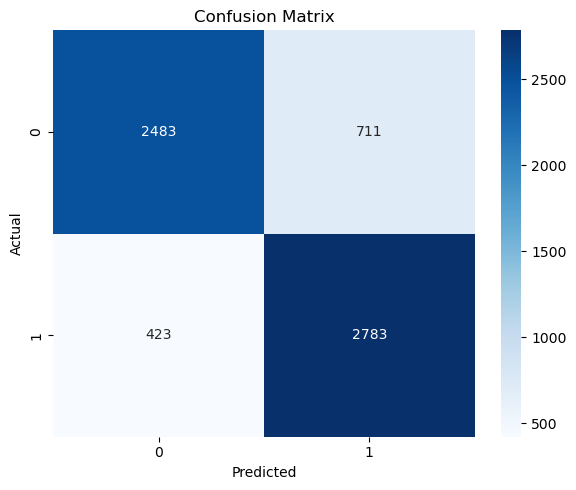


--- Evaluation Metrics for shadow model 2/5 ---
Classifier Accuracy: 0.8278125
Classifier F1 Score: 0.8272185638131075
Classification Report:
               precision    recall  f1-score   support

         0.0       0.82      0.83      0.83      3194
         1.0       0.83      0.82      0.83      3206

    accuracy                           0.83      6400
   macro avg       0.83      0.83      0.83      6400
weighted avg       0.83      0.83      0.83      6400



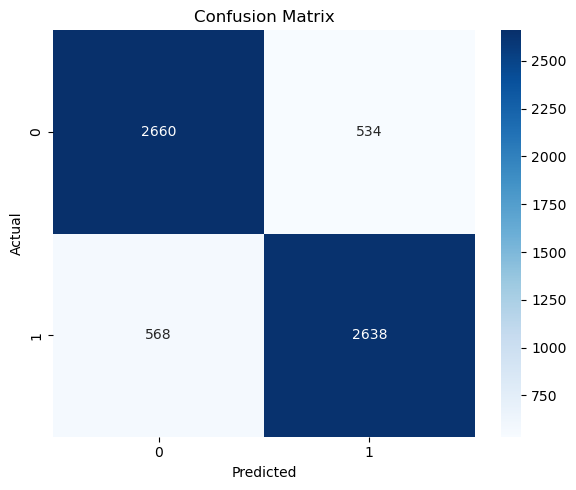


--- Evaluation Metrics for shadow model 3/5 ---
Classifier Accuracy: 0.82953125
Classifier F1 Score: 0.8289164183785479
Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.83      0.83      3194
         1.0       0.83      0.82      0.83      3206

    accuracy                           0.83      6400
   macro avg       0.83      0.83      0.83      6400
weighted avg       0.83      0.83      0.83      6400



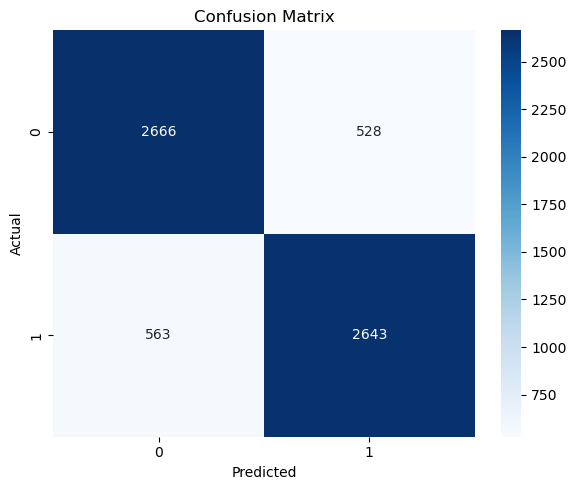


--- Evaluation Metrics for shadow model 4/5 ---
Classifier Accuracy: 0.8290625
Classifier F1 Score: 0.8340412621359223
Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      0.80      0.82      3194
         1.0       0.81      0.86      0.83      3206

    accuracy                           0.83      6400
   macro avg       0.83      0.83      0.83      6400
weighted avg       0.83      0.83      0.83      6400



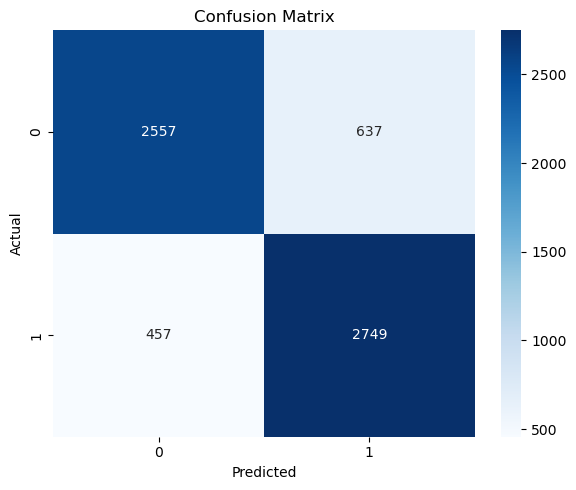


--- Evaluation Metrics for shadow model 5/5 ---
Classifier Accuracy: 0.78953125
Classifier F1 Score: 0.8083108011953892
Classification Report:
               precision    recall  f1-score   support

         0.0       0.86      0.69      0.77      3194
         1.0       0.74      0.89      0.81      3206

    accuracy                           0.79      6400
   macro avg       0.80      0.79      0.79      6400
weighted avg       0.80      0.79      0.79      6400



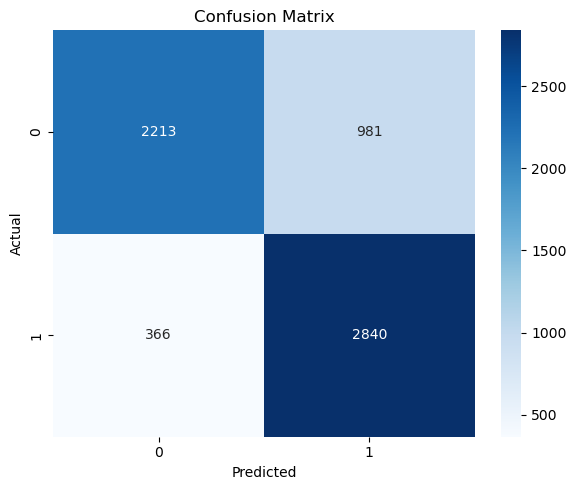

In [21]:
# ====================================
# Step 5: Evaluation and Visualization
# ====================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

''' Done in previous step
y_pred_prob = clf_model.predict(diff_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
'''
for i in range(k):
    print(f"\n--- Evaluation Metrics for shadow model {i+1}/{k} ---")
    print("Classifier Accuracy:", acc[i])
    print("Classifier F1 Score:", f1[i])
    print("Classification Report:\n", classification_report(y_test[i], y_pred[i]))

    # Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_test[i], y_pred[i]), annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(f"confusionMatrixs/confusion_matrix_shadow{i}.png")
    plt.show()
    # clf_model.save(f"classifiers/snn_classifier_model{i}.h5") Save snn classifier for each shadow model

In [22]:
for i in range(k):
    print(f"\n--- Training data distribution for shadow model {i+1}/{k} ---")
    print("Train label distribution:")
    print(pd.Series(y_train[i]).value_counts())


--- Training data distribution for shadow model 1/5 ---
Train label distribution:
1.0    12825
0.0    12775
Name: count, dtype: int64

--- Training data distribution for shadow model 2/5 ---
Train label distribution:
1.0    12825
0.0    12775
Name: count, dtype: int64

--- Training data distribution for shadow model 3/5 ---
Train label distribution:
1.0    12825
0.0    12775
Name: count, dtype: int64

--- Training data distribution for shadow model 4/5 ---
Train label distribution:
1.0    12825
0.0    12775
Name: count, dtype: int64

--- Training data distribution for shadow model 5/5 ---
Train label distribution:
1.0    12825
0.0    12775
Name: count, dtype: int64


In [27]:
# =========================================
# Learn threshold using raw BERT embeddings
# =========================================

from tensorflow.keras.layers import Dropout
from sklearn.metrics import precision_recall_fscore_support

for i in range(k):
    print(f"\n--- Training MLP Classifier on Raw BERT Embeddings for shadow model {i+1}/{k} ---")
    # -------------------------------------------------------
    # Step 1: Compute absolute differences from raw BERT embeddings
    # -------------------------------------------------------

    X_train_full = np.abs(x1_train[i] - x2_train[i])
    X_test = np.abs(x1_test[i] - x2_test[i])

    # -------------------------------------------------------
    # Step 2: Create pseudo-validation split
    # -------------------------------------------------------

    X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_full, y_train[i], test_size=0.2, random_state=42, stratify=y_train[i]
    )

    # -------------------------------------------------------
    # Step 3: Build and Train MLP Classifier
    # -------------------------------------------------------

    input_dim = X_train_final.shape[1]
    input_layer = Input(shape=(input_dim,))
    x = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01))(input_layer)
    x = Dropout(0.5)(x)
    x = Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    output = Dense(1, activation='sigmoid')(x)

    clf_model = Model(inputs=input_layer, outputs=output)
    clf_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    clf_model.fit(X_train_final, y_train_final, epochs=30, batch_size=256, validation_split=0.1)
    # clf_model.save("mlp_raw_diff_classifier.h5")

    # -------------------------------------------------------
    # Step 4: Tune threshold on validation set
    # -------------------------------------------------------

    y_val_prob = clf_model.predict(X_val).flatten()

    best_threshold = 0.5
    best_f1 = 0

    for threshold in np.arange(0.1, 0.9, 0.01):
        y_pred_val = (y_val_prob >= threshold).astype(int)
        _, _, f1[i], _ = precision_recall_fscore_support(y_val, y_pred_val, average='binary')
        if f1[i] > best_f1:
            best_f1 = f1[i]
            best_threshold = threshold

    print(f"\nBest Threshold (on pseudo-val set): {best_threshold:.2f} — Best F1 Score: {best_f1:.4f}")

    # -------------------------------------------------------
    # Step 5: Evaluate on true test set using tuned threshold
    # -------------------------------------------------------

    y_test_prob = clf_model.predict(X_test).flatten()
    y_test_pred = (y_test_prob >= best_threshold).astype(int)

    acc[i] = accuracy_score(y_test[i], y_test_pred)
    f1[i] = f1_score(y_test[i], y_test_pred)

    print("\nFinal Evaluation on Test Set:")
    print(f"Accuracy: {acc[i]:.4f}")
    print(f"F1 Score: {f1[i]:.4f}")
    print("\nDetailed Report:\n", classification_report(y_test[i], y_test_pred))

    # Save predictions
    pd.DataFrame({
    "True Label": y_test[i],
    "Predicted Label": y_test_pred,
    "Confidence": y_test_prob
    }).to_csv(f"testPredictions/final_test_predictions_raw_mlp_shadow{i}.csv", index=False)
    print("Test predictions saved")



--- Training MLP Classifier on Raw BERT Embeddings for shadow model 1/5 ---
Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7094 - loss: 1.3866 - val_accuracy: 0.8550 - val_loss: 0.8194
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8366 - loss: 0.6878 - val_accuracy: 0.8804 - val_loss: 0.5355
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8619 - loss: 0.5154 - val_accuracy: 0.8696 - val_loss: 0.4645
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8703 - loss: 0.4470 - val_accuracy: 0.8975 - val_loss: 0.3961
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8736 - loss: 0.4150 - val_accuracy: 0.8994 - val_loss: 0.3694
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8773 - loss: 0.3900 - val_accuracy: 0.8862 - val_loss: 0.3701
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8707 - loss: 0.3926 - val_accuracy: 0.8945 - val_loss: 0.3557
Epoch 8/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 